In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics_df = pd.read_csv('./stats/sim_270/model_stats.csv', index_col='dataset_name')
metrics_df

,ACC,Balanced_ACC,Precision,Recall,AUROC,AUPRC,MCC,n_estimators,min_samples_split,min_samples_leaf,max_samples,max_depth,seed,freq,size,noise
dataset_name,,,,,,,,,,,,,,,,
simulated_seed3_freq010_size1000_noise5_dataset,1.000,1.000,1.000000,1.00,1.0000,1.000000,1.000000,500,5,10,0.8,20.0,3,10,1000,5
simulated_seed3_freq010_size1000_noise25_dataset,0.985,0.985,0.989899,0.98,0.9998,0.999801,0.970049,500,2,1,NaN,10.0,3,10,1000,25
simulated_seed3_freq010_size1000_noise50_dataset,0.955,0.955,0.959596,0.95,0.9822,0.979957,0.910046,500,10,1,0.8,20.0,3,10,1000,50
simulated_seed3_freq010_size1000_noise60_dataset,0.845,0.845,0.841584,0.85,0.9270,0.912666,0.690035,500,10,1,0.8,20.0,3,10,1000,60
simulated_seed3_freq010_size1000_noise70_dataset,0.795,0.795,0.804124,0.78,0.8494,0.831306,0.590266,500,10,1,0.8,20.0,3,10,1000,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
simulated_seed7_freq050_size150_noise25_dataset,1.000,1.000,1.000000,1.00,1.0000,1.000000,1.000000,500,5,10,0.8,20.0,7,50,150,25
simulated_seed7_freq050_size150_noise50_dataset,1.000,1.000,1.000000,1.00,1.0000,1.000000,1.000000,500,5,10,0.8,20.0,7,50,150,50
simulated_seed7_freq050_size150_noise60_dataset,1.000,1.000,1.000000,1.00,1.0000,1.000000,1.000000,500,5,10,0.8,20.0,7,50,150,60


In [6]:
metrics_df.groupby(['size', 'noise']).agg({'AUPRC': ['mean','std'],
                                           'AUROC': ['mean', 'std'],
                                           'MCC': ['mean', 'std']})

AUPRC               AUROC                 MCC          
                mean       std      mean       std      mean       std
size noise                                                            
50   5      0.939753  0.155148  0.933333  0.172047  0.844444  0.343188
     25     0.915847  0.163281  0.897778  0.194022  0.729592  0.355968
     50     0.815273  0.199975  0.751111  0.271129  0.421386  0.504583
     60     0.719709  0.247549  0.617778  0.338887  0.201833  0.505804
     70     0.615882  0.272080  0.497778  0.377948  0.115042  0.598851
     80     0.537601  0.176064  0.386667  0.255343 -0.140014  0.440136
100  5      0.990183  0.023847  0.988889  0.026667  0.944836  0.112088
     25     0.931113  0.165596  0.931111  0.157277  0.811055  0.369088
     50     0.897507  0.153724  0.910000  0.133978  0.758468  0.330314
     60     0.847963  0.222234  0.825556  0.240786  0.569797  0.438784
     70     0.797835  0.229671  0.734444  0.306925  0.364084  0.570779
     80     0.843463  0.214032  0.795556  0.272310  0.513661  0.442656
150  5      0.999537  0.001389  0.999506  0.001481  0.992824  0.021529
     25     0.975981  0.067188  0.976296  0.066258  0.927874  0.172122
     50     0.971693  0.063758  0.972346  0.055767  0.884805  0.191962
     60     0.939194  0.156839  0.936790  0.155473  0.838870  0.326706
     70     0.925387  0.145953  0.922222  0.141796  0.752883  0.326176
     80     0.890262  0.190646  0.867407  0.221047  0.642250  0.440777
200  5      0.996990  0.009030  0.995556  0.013333  0.984414  0.046758
     25     0.986966  0.038217  0.983611  0.048236  0.944653  0.148616
     50     0.963188  0.087432  0.962361  0.088870  0.848972  0.284309
     60     0.941681  0.160614  0.930694  0.191747  0.839268  0.362831
     70     0.899293  0.205566  0.882222  0.242466  0.724630  0.506939
     80     0.877036  0.197049  0.879722  0.203176  0.714399  0.383141
1000 5      1.000000  0.000000  1.000000  0.000000  1.000000  0.000000
     25     0.999978  0.000066  0.999978  0.000067  0.996672  0.009984
     50     0.997773  0.006681  0.998022  0.005933  0.990005  0.029985
     60     0.990263  0.029099  0.991856  0.024321  0.964454  0.102960
     70     0.980471  0.055981  0.982433  0.049944  0.937862  0.136989
     80     0.963047  0.107695  0.958922  0.120039  0.887877  0.275859

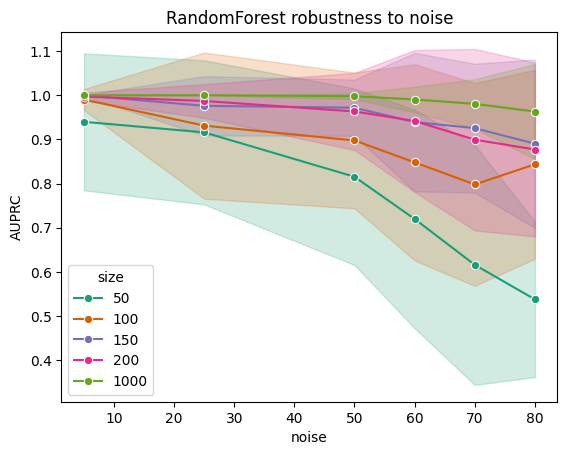

In [7]:
for metric in ['ACC', 'Balanced_ACC', 'Precision', 'Recall', 'AUROC', 'AUPRC', 'MCC'][5:6]:
    sns.lineplot(
        data=metrics_df,
        x="noise",
        y=metric,
        hue="size",
        marker="o",
        errorbar='sd',
        palette="Dark2"
    )

    plt.title("RandomForest robustness to noise")
    plt.show()

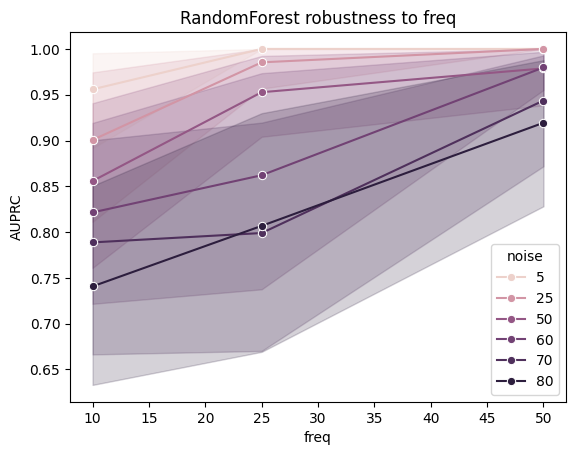

In [8]:
for metric in ['ACC', 'Balanced_ACC', 'Precision', 'Recall', 'AUROC', 'AUPRC', 'MCC'][5:6]:
    sns.lineplot(
    data=metrics_df,
    x="freq",
    y=metric,
    hue="noise",
    marker="o"
    )

    plt.title("RandomForest robustness to freq")
    plt.show()

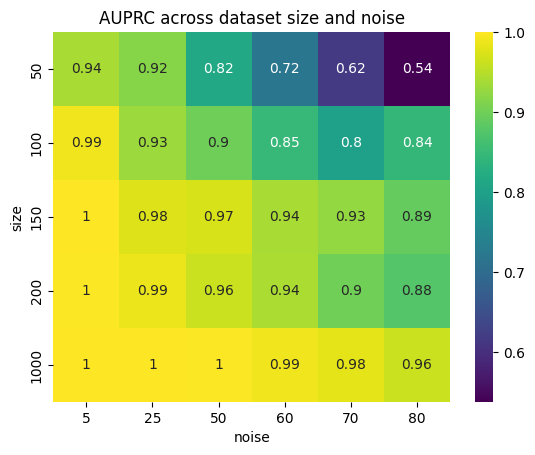

In [9]:
for metric in ['ACC', 'Balanced_ACC', 'Precision', 'Recall', 'AUROC', 'AUPRC', 'MCC'][5:6]:
    pivot = metrics_df.pivot_table(
        values=metric,
        index="size",
        columns="noise"
    )

    sns.heatmap(pivot, annot=True, cmap="viridis")
    plt.title(f"{metric} across dataset size and noise")
    plt.show()

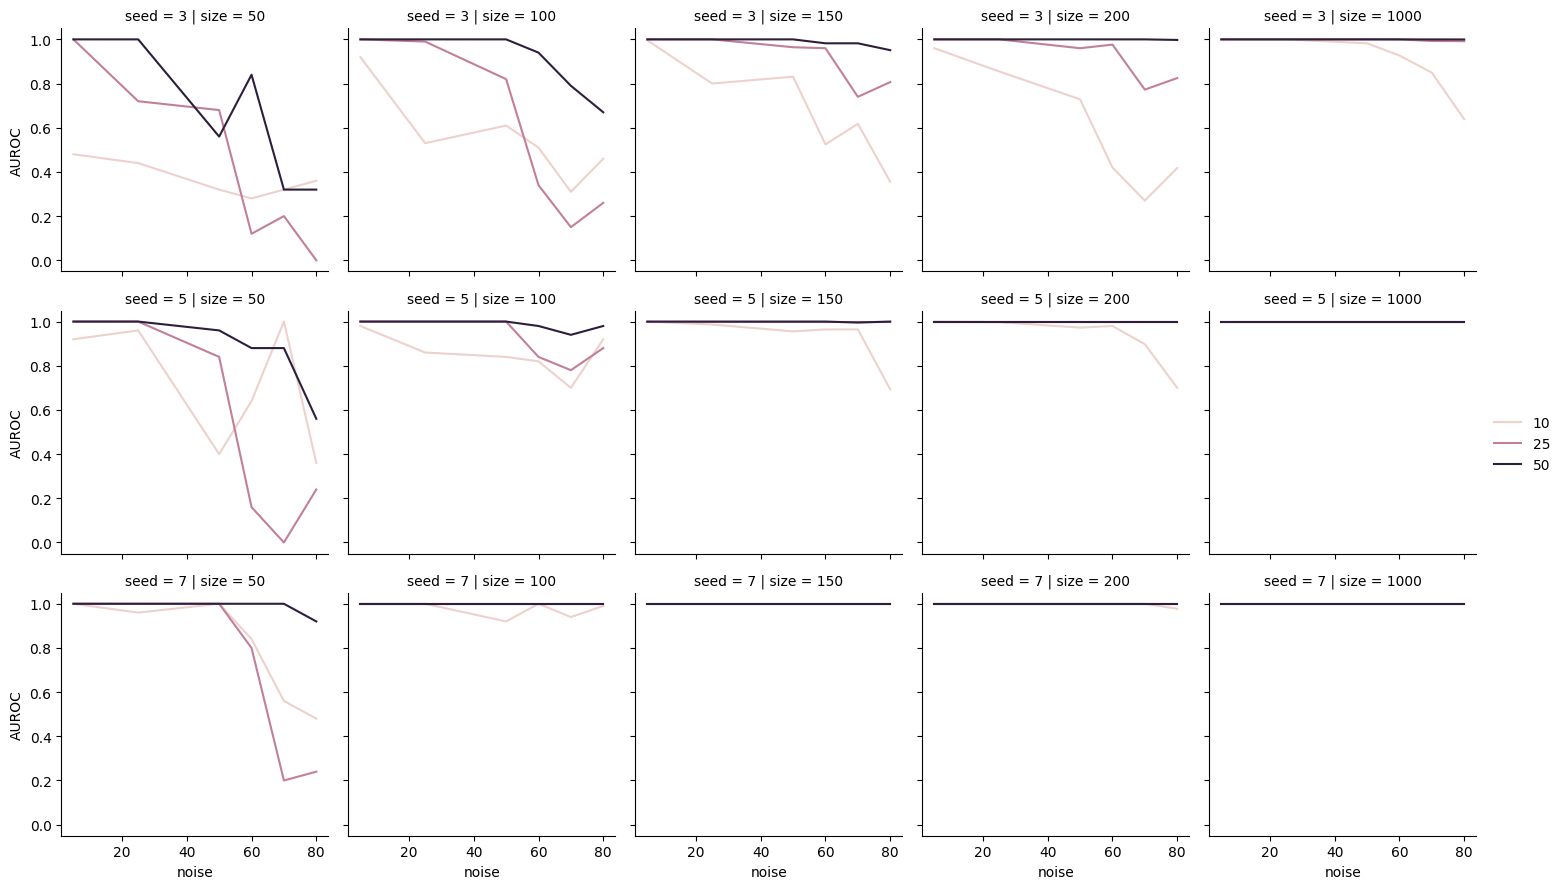

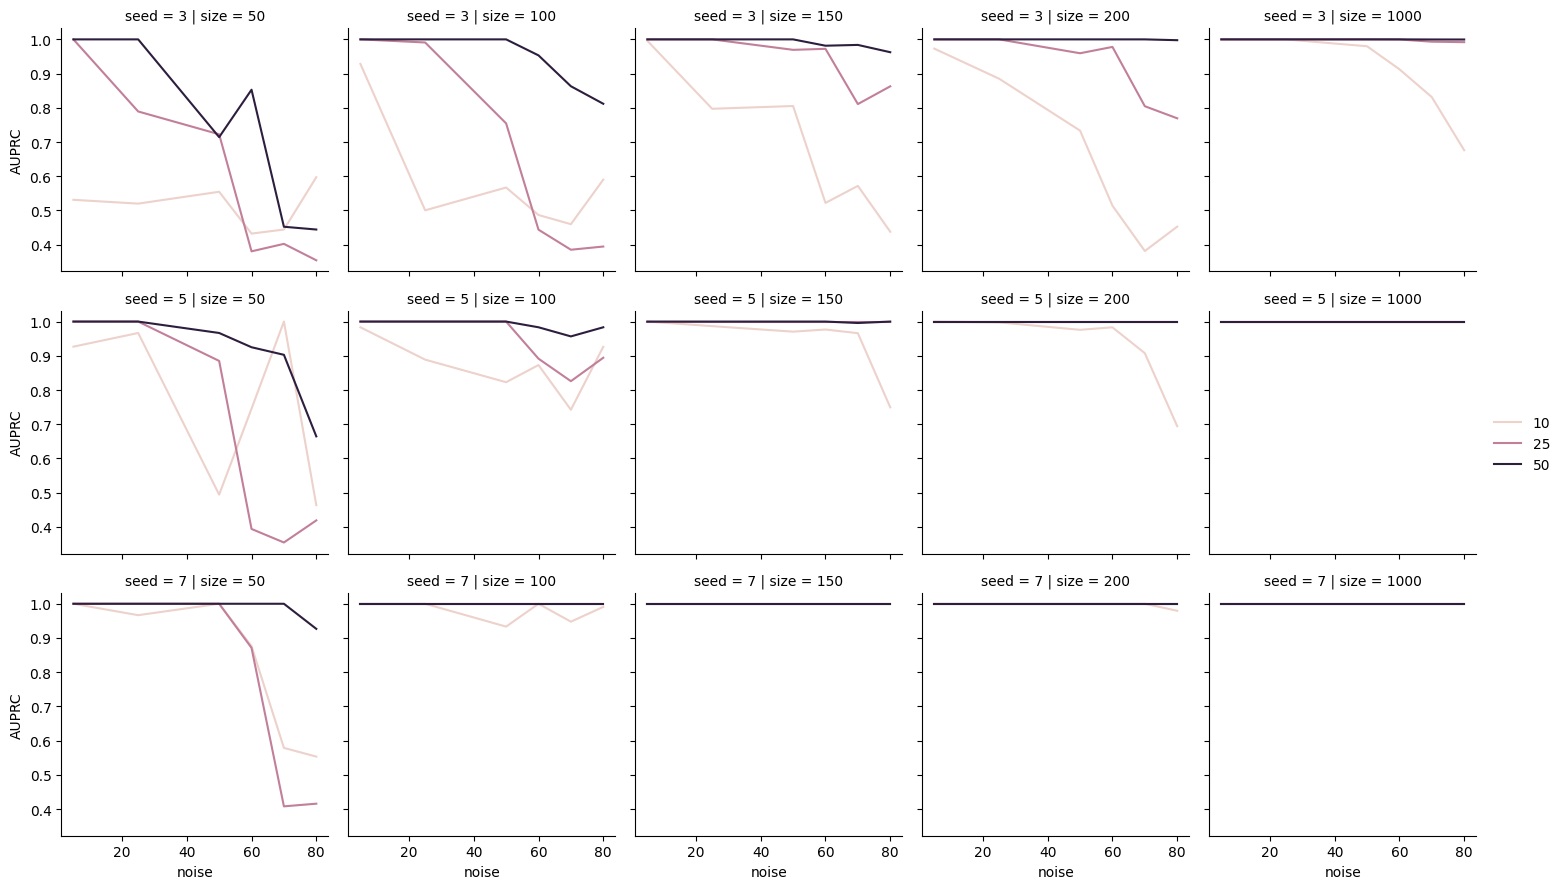

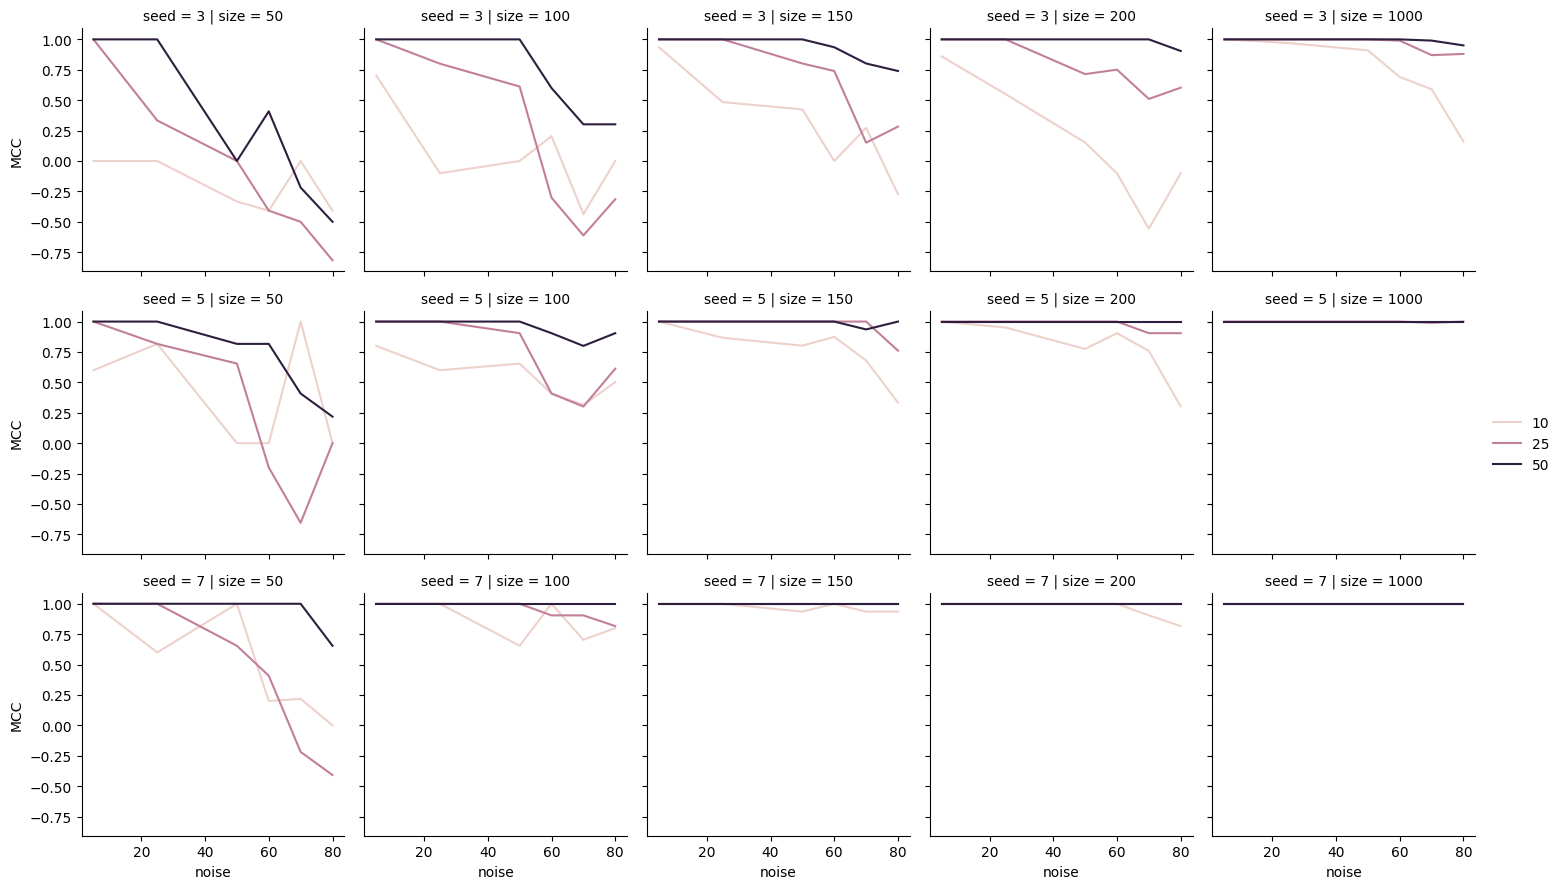

In [14]:
for metric in ['AUROC', 'AUPRC', 'MCC']: # ['ACC', 'Balanced_ACC', 'Precision', 'Recall', 'AUROC', 'AUPRC', 'MCC']:
    g = sns.FacetGrid(metrics_df, col="size", row="seed")

    g.map_dataframe(
        sns.lineplot,
        x="noise",
        y=metric,
        hue="freq"
    )

    g.add_legend()

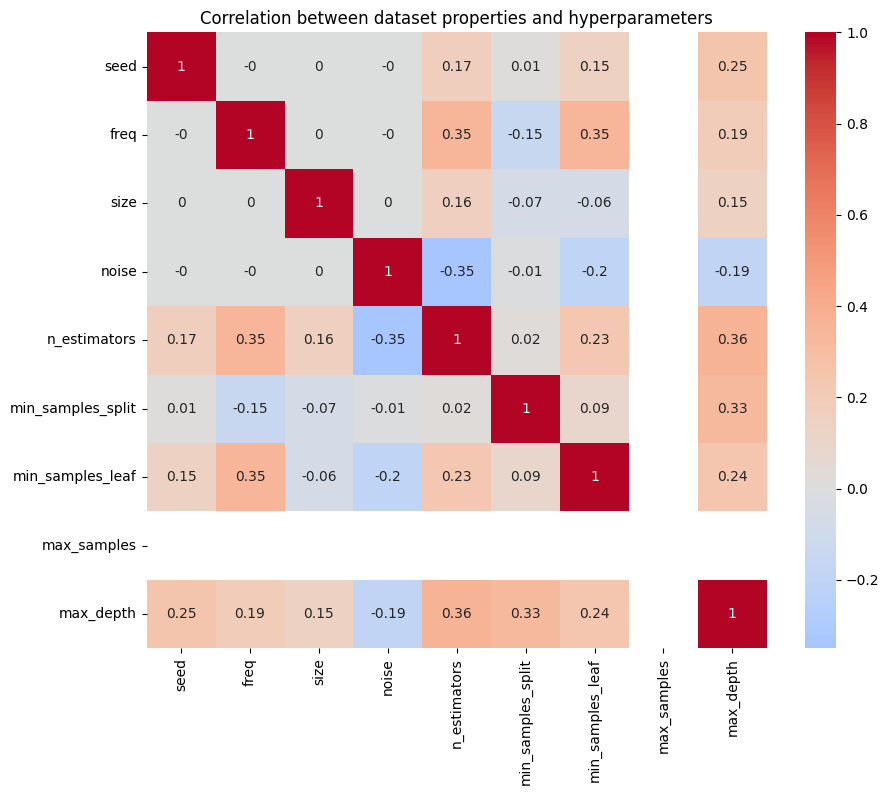

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['seed','freq','size','noise',
        'n_estimators','min_samples_split','min_samples_leaf','max_samples','max_depth']

corr = metrics_df[cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(round(corr, 2), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation between dataset properties and hyperparameters")
plt.show()


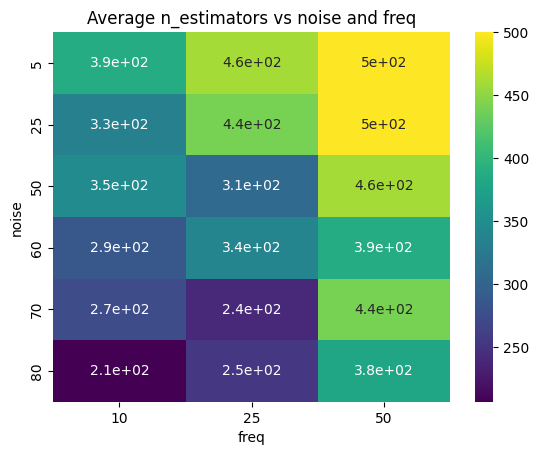

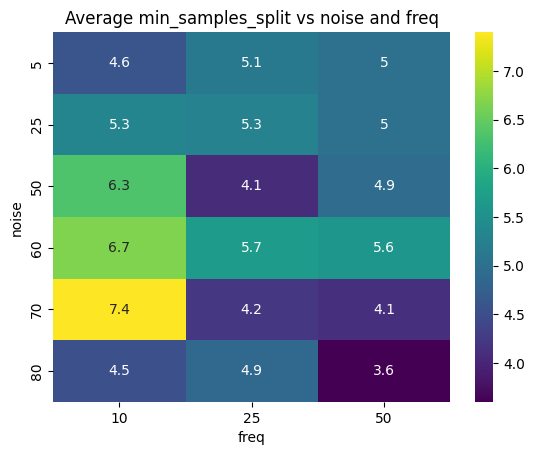

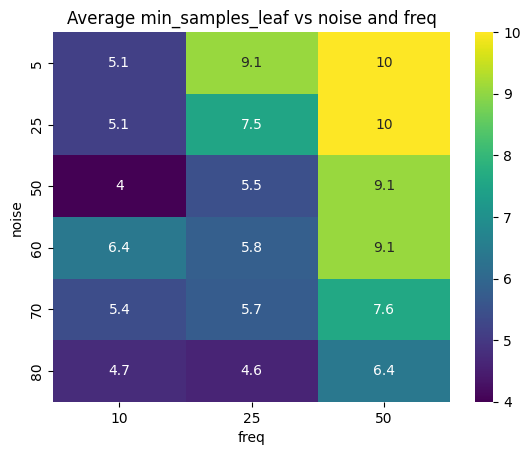

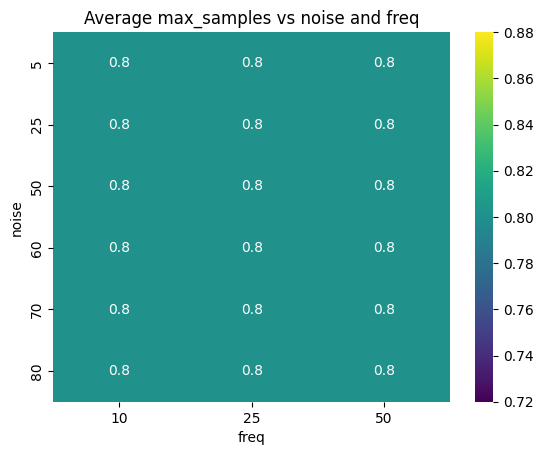

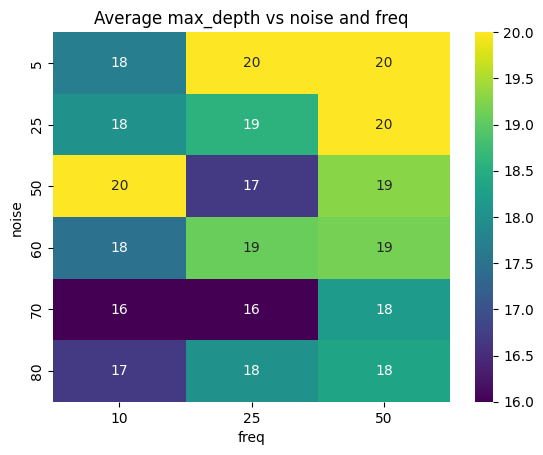

In [ ]:
for hyp in ['n_estimators','min_samples_split','min_samples_leaf','max_depth']:
    pivot = metrics_df.pivot_table(
        values=hyp,
        index="noise",
        columns="freq",
        aggfunc="mean"
    )

    sns.heatmap(pivot, annot=True, cmap="viridis")
    plt.title(f"Average {hyp} vs noise and freq")
    plt.show()


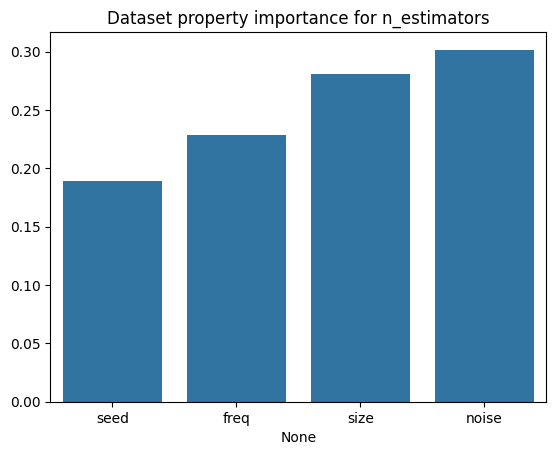

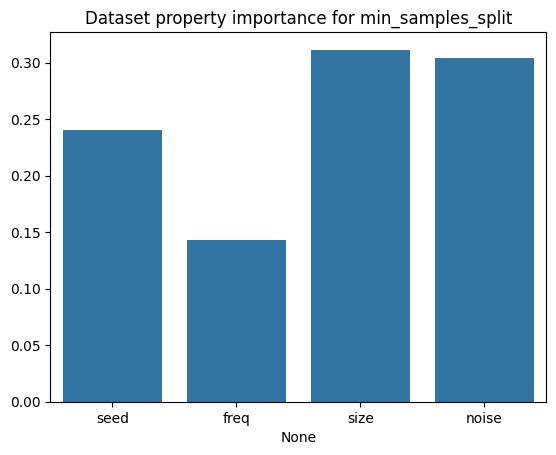

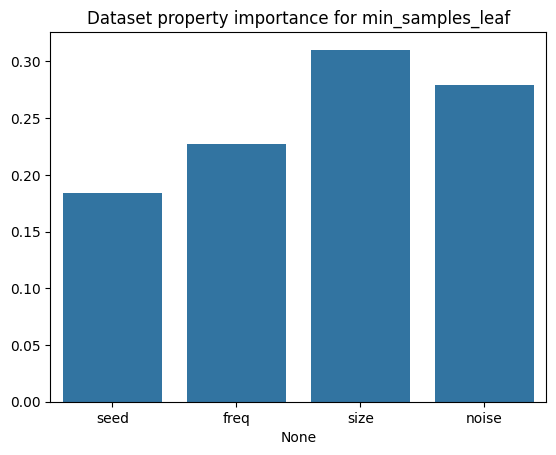

In [31]:
from sklearn.ensemble import RandomForestRegressor

for hyp in ['n_estimators','min_samples_split','min_samples_leaf']: #,'max_samples','max_depth']:
    X = metrics_df[['seed','freq','size','noise']]
    y = metrics_df[hyp]

    model = RandomForestRegressor()
    model.fit(X,y)

    importances = model.feature_importances_

    sns.barplot(x=X.columns, y=importances)
    plt.title(f"Dataset property importance for {hyp}")
    plt.show()